# SentenceSplitter — Annotation Sampling Pipeline

**GitHub issue placeholder:** `psytechlab/SentenceSplitter#TBD` — stratified sampling for Label Studio annotation batch.

## Purpose

This notebook samples ~`TARGET_N` rows from two Russian text corpora
(`presuicidal` and `solyanka`) using heuristic-based stratified selection,
deduplicates, removes leakage against held-out annotation data, and exports
Parquet + CSV artifacts ready for Label Studio.

## Strata logic summary

Complexity is decided by **V1**: `is_complex(text) = has_conjunction(text) OR has_asyndetic_markers(text)`, imported from `heuristics.filters`.  
V2 (finite-verb gating) was **rejected** — see [`validation.md`](./heuristics/validation.md) for full analysis.  
V1 achieves perfect recall (R=1.000) on Shirin's 120 confirmed-complex sentences; V2 sacrificed ~25% recall for a precision improvement that disappeared under cleaner ground-truth handling.

Edge-case annotation rules are documented in [`edge_cases.md`](./edge_cases.md) (source: annotation instruction doc retrieved 2026-05-07).

EDA reports:
- [`eda/presuicidal/summary.md`](./eda/presuicidal/summary.md)
- [`eda/solyanka/summary.md`](./eda/solyanka/summary.md)
- [`eda/comparison.md`](./eda/comparison.md)

In [1]:
# ============================================================
# CONFIG — all tunable parameters live here.
# Reference: psytechlab/SentenceSplitter#TBD
# Case holder feedback (Igor Buyanov): TARGET_N reduced to 200; "other" stratum
# added at 5% as a safety net for heuristic false negatives; existing proportions
# rescaled by 0.95 so the total still sums to 1.0.
# ============================================================

TARGET_N = 200  # confirmed by case holder (Igor Buyanov)
SEED = 42

# Long-sentence thresholds derived from EDA p75 token counts.
# Source: eda/presuicidal/summary.md (p75=20) and eda/solyanka/summary.md (per-source p75).
THRESHOLDS = {
    "presuicidal": {"long_tokens": 20},
    "solyanka": {
        "lj":           {"long_tokens": 26},
        "lenta":        {"long_tokens": 20},
        "twitter":      {"long_tokens": 14},
        "social_media": {"long_tokens": 14},
    }
}

SOURCES = [
    "psytechlab/presuisidal_antisuisidal_dataset-master",
    "psytechlab/solyanka_emotion_dataset",
]

# Must sum to 1.0.
# Original 8 proportions rescaled by 0.95; "other" added at 0.05.
# Per Igor Buyanov: "other" rows are sentences not captured by any explicit
# stratum — a safety net for heuristic false negatives.
STRATA_PROPORTIONS = {
    "presuicidal_multilabel_conj":   0.2375,   # was 0.25  * 0.95
    "presuicidal_multilabel_bsp":    0.1425,   # was 0.15  * 0.95
    "presuicidal_monolabel_long":    0.1900,   # was 0.20  * 0.95
    "presuicidal_short_simple":      0.0950,   # was 0.10  * 0.95
    "solyanka_lenta_long":           0.1140,   # was 0.12  * 0.95
    "solyanka_lj_long":              0.0950,   # was 0.10  * 0.95
    "solyanka_social_media_multi":   0.0475,   # was 0.05  * 0.95
    "solyanka_twitter_short_simple": 0.0285,   # was 0.03  * 0.95
    "other":                         0.0500,   # new: heuristic false-negative safety net
}

DATA_PATHS = {
    "presuicidal_train": "./data/presuicidal_train.parquet",
    "solyanka_train":    "./data/solyanka_train.parquet",
    # Test split for leakage reference is loaded directly from HuggingFace
    # in the data-load section (no local parquet required).
    "shirin_120":        "./data/data.csv",
}

OUTPUT_DIR = "./data"  # per Igor Buyanov: output to ./data, not notebooks/sampling/output

# Guard: proportions must sum to 1.0
assert abs(sum(STRATA_PROPORTIONS.values()) - 1.0) < 1e-9, (
    f"STRATA_PROPORTIONS sum = {sum(STRATA_PROPORTIONS.values()):.6f}, expected 1.0"
)
print("Config OK — proportions sum to", round(sum(STRATA_PROPORTIONS.values()), 10))

Config OK — proportions sum to 1.0


In [2]:
# ============================================================
# Imports & setup
# ============================================================
import random
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.use("Agg")  # headless-safe; inline backend takes over in Jupyter
%matplotlib inline

# --- RNG seeding (determinism) ---
random.seed(SEED)
np.random.seed(SEED)

# --- sys.path shim so `from heuristics.filters import ...` works regardless of CWD ---
# The heuristics module lives at notebooks/sampling/heuristics/
_SAMPLING_DIR = Path("./notebooks/sampling").resolve()
if str(_SAMPLING_DIR) not in sys.path:
    sys.path.insert(0, str(_SAMPLING_DIR))

# Import heuristic functions — do NOT reimplement inline.
# filters.is_complex is V1 (conjunction OR asyndetic). V2 was rejected — see
# notebooks/sampling/heuristics/validation.md for the analysis.
from heuristics.filters import (
    has_conjunction,
    has_asyndetic_markers,
    is_multilabel,
    token_length,
    count_finite_verbs,   # imported but NOT used as a gate (V2 rejected)
    is_complex,           # V1: conj OR bsp
)

print("Imports OK.")
print(f"  heuristics module loaded from: {_SAMPLING_DIR}")

Imports OK.
  heuristics module loaded from: /Users/dtsyplyackov/Documents/itmo/SentenceSplitter/notebooks/sampling


## 3. Load data

Load both train parquets and Shirin's 120-row annotation CSV.  
Attempt to load a presuicidal test split for leakage reference — if absent, continue with `test_df = None`.

In [3]:
# ============================================================
# Load presuicidal train
# ============================================================
_pre_path = Path(DATA_PATHS["presuicidal_train"])
pre_df = pd.read_parquet(_pre_path)
print(f"presuicidal_train: {pre_df.shape[0]:,} rows x {pre_df.shape[1]} cols")
print(pre_df.dtypes)
pre_df.head(3)

presuicidal_train: 43,584 rows x 3 cols
data_id    str
text       str
label      str
dtype: object


,data_id,text,label
0,a6b119f64c22431a823dbbb6508996f4-73,"но ее истерика потом закончилась, я очень испу...",нерелевантный
1,8f1b9395e30b4398966030917c07bff4-0,Я не знаю как больше жить дальше.,"чувства/беспомощность, безвыходность, безнадеж..."
2,a2bf76a0c2794efdbd57dab70d1484f4-1,"Иногда мне кажется, что я абсолютно одинока.","чувства/одиночество, непонимание, изоляция, бр..."


In [4]:
# ============================================================
# Load solyanka train
# ============================================================
_sol_path = Path(DATA_PATHS["solyanka_train"])
sol_df = pd.read_parquet(_sol_path)
print(f"solyanka_train: {sol_df.shape[0]:,} rows x {sol_df.shape[1]} cols")
print(sol_df.dtypes)
sol_df.head(3)

solyanka_train: 9,790 rows x 4 cols
text           str
source         str
label          str
src_dataset    str
dtype: object


,text,source,label,src_dataset
0,Суровый гималайский медведь .,lj,no_emotion,cedr
1,"Так, обнаружено несколько проблем с дисплеем (...",lenta,no_emotion,cedr
2,У меня остается только один вопрос - является ...,lj,surprise,cedr


In [5]:
# ============================================================
# Load presuicidal test split (for leakage reference) — directly from HuggingFace.
# We don't have a local test parquet, so pull the held-out split from the
# canonical dataset on the Hub. If unreachable, this MUST raise loudly rather
# than silently skip — see the except branch.
# ============================================================
from datasets import load_dataset

try:
    test_ds = load_dataset(
        "psytechlab/presuisidal_antisuisidal_dataset-master",
        split="test",
    )
    test_texts = set(test_ds["text"])
    test_df = pd.DataFrame({"text": list(test_texts)})
    print(f"presuicidal test split loaded from HF: {len(test_ds):,} rows, "
          f"{len(test_texts):,} unique texts")
except Exception as e:
    test_df = None
    test_texts = set()
    warnings.warn(
        f"FAILED to load presuicidal test split from HuggingFace: {type(e).__name__}: {e}. "
        "Leakage check against the test split will be SKIPPED. "
        "Investigate before relying on this notebook's output."
    )
    print("ERROR: HF test split unreachable — leakage check against it will be SKIPPED.")
    print(f"  Exception: {type(e).__name__}: {e}")

presuicidal test split loaded from HF: 9,777 rows, 9,777 unique texts


In [6]:
# ============================================================
# Load Shirin's 120-row annotation CSV
# ============================================================
_shirin_path = Path(DATA_PATHS["shirin_120"])
shirin_df = pd.read_csv(_shirin_path)
print(f"shirin_120: {shirin_df.shape[0]:,} rows, columns: {shirin_df.columns.tolist()}")
shirin_df.head(2)

shirin_120: 120 rows, columns: ['agreement', 'annotation_id', 'annotator', 'created_at', 'data_id', 'id', 'label', 'lead_time', 'simple_sentences', 'text', 'updated_at']


,agreement,annotation_id,annotator,created_at,data_id,id,label,lead_time,simple_sentences,text,updated_at
0,100.0,91066811.0,a.shirin300101@gmail.com,2026-03-28T11:03:54.241935Z,02786b7c4df24164bfd1b536cb1f47bd-5,257100292,"чувства/одиночество, непонимание, изоляция, бр...",261.347,"{""text"":[""Грустно."",""Ведь мне не с кем даже по...","Грустно, ведь мне не с кем даже посмеяться над...",2026-03-28T11:03:54.241947Z
1,100.0,91067000.0,a.shirin300101@gmail.com,2026-03-28T11:09:49.681310Z,17a8af6ef4544988805c03ad361be4eb-0,257100293,"клинические проявления/плач, истерики",354.045,"{""text"":[""Сегодня вечером я плачу от того."",""(...",Сегодня вечером я плачу от того что живу в Рос...,2026-03-28T11:09:49.681322Z


## 4. Apply heuristics

Add computed columns to both dataframes:
- `is_multilabel` — more than one label in the label string
- `has_conjunction` — regex match against ССП/СПП conjunction list
- `has_asyndetic` — BSP punctuation split heuristic
- `token_length` — token count via razdel (whitespace fallback)
- `is_complex` — V1: conjunction OR asyndetic marker

This cell may take a minute on ~43k presuicidal rows.

In [7]:
# ============================================================
# Apply heuristics to presuicidal
# ============================================================
print("Computing heuristics for presuicidal...")
pre_df["is_multilabel"]      = pre_df["label"].apply(lambda l: is_multilabel(l, "presuicidal"))
pre_df["has_conjunction"]    = pre_df["text"].apply(has_conjunction)
pre_df["has_asyndetic"]      = pre_df["text"].apply(has_asyndetic_markers)
pre_df["token_length"]       = pre_df["text"].apply(token_length)
pre_df["is_complex"]         = pre_df["text"].apply(is_complex)  # V1
print("presuicidal heuristic columns added.")

# ============================================================
# Apply heuristics to solyanka
# ============================================================
print("Computing heuristics for solyanka...")
sol_df["is_multilabel"]      = sol_df["label"].apply(lambda l: is_multilabel(l, "solyanka"))
sol_df["has_conjunction"]    = sol_df["text"].apply(has_conjunction)
sol_df["has_asyndetic"]      = sol_df["text"].apply(has_asyndetic_markers)
sol_df["token_length"]       = sol_df["text"].apply(token_length)
sol_df["is_complex"]         = sol_df["text"].apply(is_complex)  # V1
print("solyanka heuristic columns added.")

# ============================================================
# Summary table
# ============================================================
summary = pd.DataFrame({
    "dataset":         ["presuicidal", "solyanka"],
    "total_rows":      [len(pre_df), len(sol_df)],
    "is_multilabel":   [pre_df["is_multilabel"].sum(), sol_df["is_multilabel"].sum()],
    "has_conjunction": [pre_df["has_conjunction"].sum(), sol_df["has_conjunction"].sum()],
    "has_asyndetic":   [pre_df["has_asyndetic"].sum(), sol_df["has_asyndetic"].sum()],
    "is_complex_v1":   [pre_df["is_complex"].sum(), sol_df["is_complex"].sum()],
    "median_tokens":   [pre_df["token_length"].median(), sol_df["token_length"].median()],
})
print("\n=== Heuristic summary ===")
summary

Computing heuristics for presuicidal...


presuicidal heuristic columns added.
Computing heuristics for solyanka...


solyanka heuristic columns added.

=== Heuristic summary ===


,dataset,total_rows,is_multilabel,has_conjunction,has_asyndetic,is_complex_v1,median_tokens
0,presuicidal,43584,11773,36164,30433,39153,16.0
1,solyanka,9790,419,6840,6172,7874,15.0


## 5. Stratum classification

Assign each row to a named stratum based on heuristic flags and per-source length thresholds.

### Presuicidal strata
| Stratum | Rule |
|---|---|
| `multilabel_conj` | is_multilabel AND has_conjunction |
| `multilabel_bsp` | is_multilabel AND has_asyndetic AND NOT has_conjunction |
| `monolabel_long` | NOT is_multilabel AND token_length >= 20 AND is_complex_v1 |
| `short_simple` | NOT is_multilabel AND token_length < 20 AND NOT is_complex_v1 |
| `other` | everything else |

### Solyanka strata
| Stratum | Rule |
|---|---|
| `lenta_long` | source=="lenta" AND token_length >= 20 AND is_complex_v1 |
| `lj_long` | source=="lj" AND token_length >= 26 AND is_complex_v1 |
| `social_media_multi` | source=="social_media" AND is_multilabel |
| `twitter_short_simple` | source=="twitter" AND token_length < 14 AND NOT is_complex_v1 |
| `other` | everything else |

Threshold sources: `eda/presuicidal/summary.md` (p75=20 tokens) and `eda/solyanka/summary.md` (per-source p75).

In [8]:
# ============================================================
# Stratum classification — presuicidal
# Thresholds from THRESHOLDS config; all values trace back to eda/presuicidal/summary.md
# ============================================================
_pre_long = THRESHOLDS["presuicidal"]["long_tokens"]  # 20

def _classify_presuicidal(row):
    ml   = row["is_multilabel"]
    conj = row["has_conjunction"]
    bsp  = row["has_asyndetic"]
    tlen = row["token_length"]
    cpx  = row["is_complex"]  # V1

    if ml and conj:
        return "multilabel_conj"
    if ml and bsp and not conj:
        return "multilabel_bsp"
    if not ml and tlen >= _pre_long and cpx:
        return "monolabel_long"
    if not ml and tlen < _pre_long and not cpx:
        return "short_simple"
    return "other"

pre_df["stratum"] = pre_df.apply(_classify_presuicidal, axis=1)

print("presuicidal stratum counts:")
print(pre_df["stratum"].value_counts().to_string())

presuicidal stratum counts:
stratum
other              18965
multilabel_conj    10620
monolabel_long      9177
short_simple        4048
multilabel_bsp       774


In [9]:
# ============================================================
# Stratum classification — solyanka
# Thresholds from THRESHOLDS config; all values trace back to eda/solyanka/summary.md
# ============================================================
_sol_thr = THRESHOLDS["solyanka"]  # dict keyed by source

def _classify_solyanka(row):
    src  = row["source"]
    ml   = row["is_multilabel"]
    tlen = row["token_length"]
    cpx  = row["is_complex"]  # V1

    if src == "lenta" and tlen >= _sol_thr["lenta"]["long_tokens"] and cpx:   # per eda: lenta p75=20
        return "lenta_long"
    if src == "lj" and tlen >= _sol_thr["lj"]["long_tokens"] and cpx:         # per eda: lj p75=26
        return "lj_long"
    if src == "social_media" and ml:
        return "social_media_multi"
    if src == "twitter" and tlen < _sol_thr["twitter"]["long_tokens"] and not cpx:  # per eda: twitter p75=14
        return "twitter_short_simple"
    return "other"

sol_df["stratum"] = sol_df.apply(_classify_solyanka, axis=1)

print("solyanka stratum counts:")
print(sol_df["stratum"].value_counts().to_string())

solyanka stratum counts:
stratum
other                   7462
lenta_long               942
lj_long                  596
twitter_short_simple     474
social_media_multi       316


## 6. Sample per stratum

For each stratum compute the target count `k` using the **largest-remainder (Hare quota) method**:
- exact quota = TARGET_N * proportion
- floor each quota to get a base allocation
- distribute the remainder (TARGET_N - sum of floors) as +1 to strata with the largest fractional parts (ties broken by stratum order)

This guarantees `sum(k) == TARGET_N` exactly, regardless of floating-point rounding in individual products.

If the pool has fewer rows than `k`, take all available and print a warning.

Sampling uses `df.sample(n=k, random_state=SEED)` for full reproducibility.

In [10]:
# ============================================================
# Build stratum -> pool mapping
# ============================================================
# Map config stratum names -> (dataframe, stratum column value)
# "other" is handled separately below (combined pool from both datasets).
_STRATUM_POOLS = {
    "presuicidal_multilabel_conj":   (pre_df, "multilabel_conj"),
    "presuicidal_multilabel_bsp":    (pre_df, "multilabel_bsp"),
    "presuicidal_monolabel_long":    (pre_df, "monolabel_long"),
    "presuicidal_short_simple":      (pre_df, "short_simple"),
    "solyanka_lenta_long":           (sol_df, "lenta_long"),
    "solyanka_lj_long":              (sol_df, "lj_long"),
    "solyanka_social_media_multi":   (sol_df, "social_media_multi"),
    "solyanka_twitter_short_simple": (sol_df, "twitter_short_simple"),
}

# ============================================================
# Build "other" pool: combine other-classified rows from BOTH datasets.
# Per Igor Buyanov: "other" rows are sentences not captured by any explicit
# stratum — a safety net for heuristic false negatives.
# source_dataset and source_subdomain are preserved from their originals.
# ============================================================
_pre_other = pre_df[pre_df["stratum"] == "other"].copy()
_pre_other_rows = pd.DataFrame({
    "text":             _pre_other["text"].values,
    "source_dataset":   "presuicidal",
    "source_subdomain": None,  # presuicidal has no source subdomain column
    "original_label":   _pre_other["label"].values,
    "stratum":          "other",
    "data_id":          _pre_other["data_id"].values,
})

_sol_other = sol_df[sol_df["stratum"] == "other"].copy()
_sol_other_rows = pd.DataFrame({
    "text":             _sol_other["text"].values,
    "source_dataset":   "solyanka",
    "source_subdomain": _sol_other["source"].values,  # lj, lenta, twitter, social_media
    "original_label":   _sol_other["label"].values,
    "stratum":          "other",
    "data_id":          None,  # solyanka has no data_id column
})

_other_pool = pd.concat([_pre_other_rows, _sol_other_rows], ignore_index=True)
print(f"'other' pool: {len(_pre_other):,} presuicidal + {len(_sol_other):,} solyanka = {len(_other_pool):,} rows total")

# ============================================================
# Compute per-stratum target counts via largest-remainder (Hare quota) method.
# This guarantees sum(_STRATA_K.values()) == TARGET_N exactly, regardless of
# how independent round() calls would accumulate rounding error.
#
# Algorithm:
#   1. exact quota_i = TARGET_N * proportion_i
#   2. floor each quota to get base allocation
#   3. remainder = TARGET_N - sum(floors)
#   4. distribute remainder as +1 to the strata with the largest fractional
#      parts, breaking ties by stratum order (deterministic/reproducible).
# ============================================================
_strata_names = list(STRATA_PROPORTIONS.keys())
_exact_quotas = [TARGET_N * STRATA_PROPORTIONS[s] for s in _strata_names]
_floors = [int(q) for q in _exact_quotas]
_fractions = [q - f for q, f in zip(_exact_quotas, _floors)]
_remainder = TARGET_N - sum(_floors)

# Sort indices by descending fractional part; stable so equal fracs keep stratum order
_order = sorted(range(len(_fractions)), key=lambda i: -_fractions[i])
_allocations = _floors[:]
for i in range(_remainder):
    _allocations[_order[i]] += 1

_STRATA_K = {s: _allocations[i] for i, s in enumerate(_strata_names)}

print("\nLargest-remainder allocation (sum must be exactly TARGET_N):")
for s, k in _STRATA_K.items():
    idx = _strata_names.index(s)
    q = _exact_quotas[idx]
    print(f"  {s:<42s}  quota={q:.4f}  floor={int(q)}  frac={q - int(q):.4f}  k={k}")
print(f"  {'TOTAL':<42s}  {'':>18}  k={sum(_STRATA_K.values())}")
assert sum(_STRATA_K.values()) == TARGET_N, (
    f"Largest-remainder allocation sums to {sum(_STRATA_K.values())}, expected {TARGET_N}"
)

# ============================================================
# Sample
# ============================================================
stratum_samples = []
shortfall_strata = []

for stratum_name, proportion in STRATA_PROPORTIONS.items():
    k = _STRATA_K[stratum_name]  # exact count from largest-remainder allocation

    # --- "other" stratum: use combined pool, schema already normalised ---
    if stratum_name == "other":
        pool_size = len(_other_pool)
        if pool_size == 0:
            warnings.warn(f"[{stratum_name}] Pool is EMPTY — skipping.")
            print(f"  WARNING [{stratum_name}]: pool=0, target={k} — SKIPPED")
            shortfall_strata.append((stratum_name, pool_size, k))
            continue
        if pool_size < k:
            warnings.warn(
                f"[{stratum_name}] Pool size {pool_size} < target {k} — taking all available."
            )
            print(f"  WARNING [{stratum_name}]: pool={pool_size} < target={k} — taking all {pool_size}")
            sampled_rows = _other_pool.copy()
            shortfall_strata.append((stratum_name, pool_size, k))
        else:
            sampled_rows = _other_pool.sample(n=k, random_state=SEED)
            print(f"  [{stratum_name}]: pool={pool_size:,}, target={k}, sampled={len(sampled_rows)}")
        stratum_samples.append(sampled_rows)
        continue

    # --- named strata: use per-dataset pools ---
    src_df, stratum_val = _STRATUM_POOLS[stratum_name]

    # Determine which dataset this row came from
    if src_df is pre_df:
        source_dataset = "presuicidal"
    else:
        source_dataset = "solyanka"

    pool = src_df[src_df["stratum"] == stratum_val].copy()
    pool_size = len(pool)

    if pool_size == 0:
        warnings.warn(f"[{stratum_name}] Pool is EMPTY — skipping.")
        print(f"  WARNING [{stratum_name}]: pool=0, target={k} — SKIPPED")
        shortfall_strata.append((stratum_name, pool_size, k))
        continue

    if pool_size < k:
        warnings.warn(
            f"[{stratum_name}] Pool size {pool_size} < target {k} — taking all available."
        )
        print(f"  WARNING [{stratum_name}]: pool={pool_size} < target={k} — taking all {pool_size}")
        sampled = pool.copy()
        shortfall_strata.append((stratum_name, pool_size, k))
    else:
        sampled = pool.sample(n=k, random_state=SEED)
        print(f"  [{stratum_name}]: pool={pool_size:,}, target={k}, sampled={len(sampled)}")

    # Normalise to common output schema:
    #   text, source_dataset, source_subdomain, original_label, stratum, data_id
    rows = pd.DataFrame({
        "text":             sampled["text"].values,
        "source_dataset":   source_dataset,
        "source_subdomain": sampled["source"].values if "source" in sampled.columns else None,
        "original_label":   sampled["label"].values,
        "stratum":          stratum_name,
        "data_id":          sampled["data_id"].values if "data_id" in sampled.columns else None,
    })
    stratum_samples.append(rows)

combined_df = pd.concat(stratum_samples, ignore_index=True)
print(f"\nCombined sample shape: {combined_df.shape}")
print(f"Shortfalls: {shortfall_strata if shortfall_strata else 'none'}")


'other' pool: 18,965 presuicidal + 7,462 solyanka = 26,427 rows total

Largest-remainder allocation (sum must be exactly TARGET_N):
  presuicidal_multilabel_conj                 quota=47.5000  floor=47  frac=0.5000  k=48
  presuicidal_multilabel_bsp                  quota=28.5000  floor=28  frac=0.5000  k=28
  presuicidal_monolabel_long                  quota=38.0000  floor=38  frac=0.0000  k=38
  presuicidal_short_simple                    quota=19.0000  floor=19  frac=0.0000  k=19
  solyanka_lenta_long                         quota=22.8000  floor=22  frac=0.8000  k=23
  solyanka_lj_long                            quota=19.0000  floor=19  frac=0.0000  k=19
  solyanka_social_media_multi                 quota=9.5000  floor=9  frac=0.5000  k=9
  solyanka_twitter_short_simple               quota=5.7000  floor=5  frac=0.7000  k=6
  other                                       quota=10.0000  floor=10  frac=0.0000  k=10
  TOTAL                                                           k=200
 

## 7. Deduplication and leakage removal

Three sequential passes:
1. **Exact text deduplication** within the combined sample.
2. **Leakage check against presuicidal test split.** Test split is loaded inline from HuggingFace — no local file dependency.
3. **Leakage check against Shirin's 120** annotation CSV — remove any overlap by exact `text` match.

In [11]:
# ============================================================
# Pass 1: exact text deduplication within sample
# ============================================================
before_dedup = len(combined_df)
combined_df = combined_df.drop_duplicates(subset=["text"]).reset_index(drop=True)
after_dedup = len(combined_df)
print(f"Pass 1 — exact text dedup: {before_dedup} -> {after_dedup} rows (dropped {before_dedup - after_dedup})")

Pass 1 — exact text dedup: 200 -> 200 rows (dropped 0)


In [12]:
# ============================================================
# Pass 2: leakage check against presuicidal test split (HF)
# ============================================================
if test_df is not None:
    # test_texts already populated in the test-split load cell above.
    before_test_leak = len(combined_df)
    combined_df = combined_df[~combined_df["text"].isin(test_texts)].reset_index(drop=True)
    after_test_leak = len(combined_df)
    dropped_test_leak = before_test_leak - after_test_leak
    print(f"Pass 2 — test-split leakage: {before_test_leak} -> {after_test_leak} rows "
          f"(dropped {dropped_test_leak})")
else:
    dropped_test_leak = None
    print("Pass 2 — test-split leakage check SKIPPED (HF load failed; see prior cell).")

Pass 2 — test-split leakage: 200 -> 200 rows (dropped 0)


In [13]:
# ============================================================
# Pass 3: leakage check against Shirin's 120 annotation CSV
# ============================================================
shirin_texts = set(shirin_df["text"].dropna().unique())
before_shirin = len(combined_df)
combined_df = combined_df[~combined_df["text"].isin(shirin_texts)].reset_index(drop=True)
after_shirin = len(combined_df)
dropped_shirin = before_shirin - after_shirin
print(f"Pass 3 — Shirin-120 leakage: {before_shirin} -> {after_shirin} rows (dropped {dropped_shirin})")

print(f"\nFinal combined shape after all dedup/leakage passes: {combined_df.shape}")

Pass 3 — Shirin-120 leakage: 200 -> 200 rows (dropped 0)

Final combined shape after all dedup/leakage passes: (200, 6)


## 8. Sanity checks

- Final stratum distribution vs. target proportions
- Token-length histogram
- 5 random examples per stratum
- Total close to `TARGET_N`

In [14]:
# ============================================================
# Final stratum distribution
# ============================================================
final_counts = combined_df["stratum"].value_counts().rename("actual")
# Use _STRATA_K (largest-remainder allocation) as target, not round(), so the
# target column sums to TARGET_N exactly.
target_counts = pd.Series(_STRATA_K, name="target")
dist = pd.concat([final_counts, target_counts], axis=1).fillna(0).astype(int)
dist["actual_%"] = (dist["actual"] / dist["actual"].sum() * 100).round(1)
dist["target_%"] = (dist["target"] / target_counts.sum() * 100).round(1)
print("=== Stratum distribution ===")
print(dist.to_string())
print(f"\nTotal actual: {dist['actual'].sum()}  |  Target: {TARGET_N}")

# Hard assertion: total must equal TARGET_N exactly (largest-remainder guarantees this
# in the absence of shortfalls or leakage drops).
total_actual = len(combined_df)
if abs(total_actual - TARGET_N) / TARGET_N > 0.10:
    warnings.warn(
        f"Final sample size {total_actual} deviates >10% from TARGET_N={TARGET_N}. "
        "Check for large shortfalls or leakage drops."
    )
else:
    print(f"\nSample-size check OK: {total_actual} rows, within 10% of TARGET_N={TARGET_N}")


=== Stratum distribution ===
                               actual  target  actual_%  target_%
presuicidal_multilabel_conj        48      48      24.0      24.0
presuicidal_monolabel_long         38      38      19.0      19.0
presuicidal_multilabel_bsp         28      28      14.0      14.0
solyanka_lenta_long                23      23      11.5      11.5
presuicidal_short_simple           19      19       9.5       9.5
solyanka_lj_long                   19      19       9.5       9.5
other                              10      10       5.0       5.0
solyanka_social_media_multi         9       9       4.5       4.5
solyanka_twitter_short_simple       6       6       3.0       3.0

Total actual: 200  |  Target: 200

Sample-size check OK: 200 rows, within 10% of TARGET_N=200


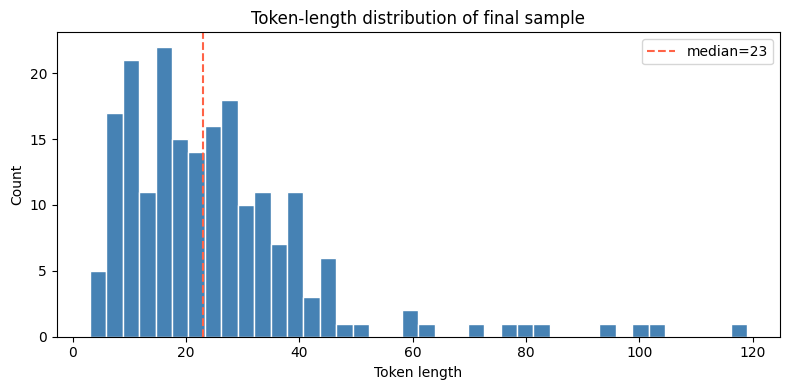

count    200.0
mean      25.4
std       18.1
min        3.0
25%       13.0
50%       23.0
75%       32.0
max      119.0


In [15]:
# ============================================================
# Token-length histogram
# ============================================================
toks = combined_df["text"].apply(token_length)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(toks, bins=40, color="steelblue", edgecolor="white")
ax.set_xlabel("Token length")
ax.set_ylabel("Count")
ax.set_title("Token-length distribution of final sample")
ax.axvline(toks.median(), color="tomato", linestyle="--", label=f"median={toks.median():.0f}")
ax.legend()
plt.tight_layout()
plt.show()
print(toks.describe().round(1).to_string())

In [16]:
# ============================================================
# 5 random examples per stratum
# ============================================================
rng = np.random.default_rng(SEED)
for stratum_name in STRATA_PROPORTIONS.keys():
    pool = combined_df[combined_df["stratum"] == stratum_name]
    n_show = min(5, len(pool))
    if n_show == 0:
        print(f"\n--- {stratum_name}: NO ROWS ---")
        continue
    sample = pool.sample(n=n_show, random_state=SEED)
    print(f"\n--- {stratum_name} ({len(pool)} rows, showing {n_show}) ---")
    for _, row in sample.iterrows():
        print(f"  [{row['source_dataset']}] {str(row['text'])[:120]}")


--- presuicidal_multilabel_conj (48 rows, showing 5) ---
  [presuicidal] Но придя домой я разревелась, чувствуя свою ущербность.
  [presuicidal] психолог сказала мне что своими истериками я манипулирую людьми чтобы они уделяли мне больше времени я и сама это понима
  [presuicidal] Да может я и глупость скажу, но сам факт Я ЖИТЬ БОЛЬШЕ НЕХОЧУ.
  [presuicidal] На свою жизнь я не жалуюсь, есть хлеб, кров и удобства Но последние месяца 4 меня постоянно посещают суицидальные мысли,
  [presuicidal] От дома мамы я в 500км+ денег ноль, срок не маленький, куда идти то?

--- presuicidal_multilabel_bsp (28 rows, showing 5) ---
  [presuicidal] В 11 классе я перешла в новую школу, в которой было прекрасно всё: я любила всех одноклассников, учителей.
  [presuicidal] Из-за девушки, отвергшей мои чувства, я хотел покончить с собой.
  [presuicidal] Вышла я с больничного другим человеком - жалким, беспомощным.
  [presuicidal] Тело онемело, затряслось, пошли слезы, я задыхался.
  [presuicidal] Моя собст

## 9. Export

Write to `OUTPUT_DIR/sample_for_annotation.parquet` and `.csv`.  
Create `OUTPUT_DIR` if missing.

In [17]:
# ============================================================
# Write outputs
# Per Igor Buyanov: output path changed to ./data (was ./notebooks/sampling/output)
# ============================================================
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

parquet_path = output_dir / "sample_for_annotation.parquet"
csv_path     = output_dir / "sample_for_annotation.csv"

combined_df.to_parquet(parquet_path, index=False)
combined_df.to_csv(csv_path, index=False)

print(f"Parquet: {parquet_path}  ({parquet_path.stat().st_size / 1024:.1f} KB, {len(combined_df)} rows)")
print(f"CSV:     {csv_path}  ({csv_path.stat().st_size / 1024:.1f} KB, {len(combined_df)} rows)")

Parquet: data/sample_for_annotation.parquet  (39.3 KB, 200 rows)
CSV:     data/sample_for_annotation.csv  (80.5 KB, 200 rows)


## 10. Summary

Final artifact stats and notes on any deviations.

In [18]:
# ============================================================
# Final summary printout
# ============================================================
print("=" * 60)
print("SAMPLING PIPELINE COMPLETE")
print("=" * 60)
print(f"  SEED:            {SEED}")
print(f"  TARGET_N:        {TARGET_N}")
print(f"  Final rows:      {len(combined_df)}")
print()
print("  Stratum counts:")
for stratum_name, cnt in combined_df["stratum"].value_counts().items():
    pct = cnt / len(combined_df) * 100
    print(f"    {stratum_name:<40s} {cnt:>5d}  ({pct:.1f}%)")
print()
print("  Dedup/leakage drops:")
print(f"    exact-text dedup:          {before_dedup - after_dedup}")
if dropped_test_leak is None:
    print(f"    presuicidal test-split:    SKIPPED (HF load failed)")
else:
    print(f"    presuicidal test-split:    {dropped_test_leak}")
print(f"    Shirin-120 leakage:        {dropped_shirin}")
print()
print(f"  Outputs:")
print(f"    {parquet_path}")
print(f"    {csv_path}")
if shortfall_strata:
    print()
    print("  SHORTFALL WARNINGS (pool < target):")
    for sname, pool_n, target_n in shortfall_strata:
        print(f"    {sname}: pool={pool_n}, target={target_n}")

SAMPLING PIPELINE COMPLETE
  SEED:            42
  TARGET_N:        200
  Final rows:      200

  Stratum counts:
    presuicidal_multilabel_conj                 48  (24.0%)
    presuicidal_monolabel_long                  38  (19.0%)
    presuicidal_multilabel_bsp                  28  (14.0%)
    solyanka_lenta_long                         23  (11.5%)
    presuicidal_short_simple                    19  (9.5%)
    solyanka_lj_long                            19  (9.5%)
    other                                       10  (5.0%)
    solyanka_social_media_multi                  9  (4.5%)
    solyanka_twitter_short_simple                6  (3.0%)

  Dedup/leakage drops:
    exact-text dedup:          0
    presuicidal test-split:    0
    Shirin-120 leakage:        0

  Outputs:
    data/sample_for_annotation.parquet
    data/sample_for_annotation.csv
